# Setup

In [1]:
%matplotlib inline

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import Image, display

# dataset dirs follow conf/dataset/*/default.yaml: ${root}/${dataset.dir}
DATA = Path('/home/nik/workspace/ImperialWork/msc_project/SyncNetProject/data')
SOC_NPZ = DATA / 'sort_of_clevr-seed1-train36000-test1000-q10-t-1' / 'test.npz'
SQOOP_NPZ = DATA / 'sqoop-seed0-train1080000-test25600-rhs18' / 'val_seen.npz'

OUT_DIR = Path('./outputs') / 'figures'
CHAP_DATASETS = OUT_DIR / 'chap:datasets'
CHAP_RESULTS = OUT_DIR / 'chap:results'
CHAP_DATASETS.mkdir(parents=True, exist_ok=True)
CHAP_RESULTS.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 140,
    'savefig.dpi': 400,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,
})


def save_show(fig, name, dir, screen_dpi=110):
    path = dir / f'{name}.png'
    fig.savefig(path)
    width = int(fig.get_size_inches()[0] * screen_dpi)   # show at screen size, not the 400-dpi pixel size
    plt.close(fig)
    display(Image(path, width=width))

In [2]:
SOC, SQ = 'sort_of_clevr', 'sqoop'
PAIR_VARIETY = [1, 2, 4, 8, 18, 35]
T_TEST = [1, 2, 4, 6, 8, 12, 16]

MAIN = {
    SOC: {
        'Q-Only': '5c938564b4',
        'CNN+MLP': '7f69d35494',
        'RelNet': '1bba57eaba',
        'FiLM': 'cce2a7dc79',
        'Transformer': 'd50b23e608',
        'Workspace': 'e2b5f79b1c',
        'SyncNet': 'bd2c173785',
    },
    SQ: {
        'Q-Only': {1: 'da868e47f3', 2: '8c385b2059', 4: 'b53f5ecb08', 8: 'c7cfb0dd1c', 18: 'd640141c57', 35: 'a09acf017b'},
        'Conv+LSTM': {1: '4dd2f8a5f6', 2: 'b838865278', 4: '11380cec6a', 8: '125ce8d50e', 18: '6828367e4c', 35: 'd6cbb5b004'},
        'RelNet': {1: 'd91b42c323', 2: '41515ce582', 4: '46ef70288f', 8: 'f15b7d0159', 18: 'fd877702cb', 35: '18a92d8762'},
        'FiLM': {1: '48c351e38b', 2: 'cbbfbd61a7', 4: '13e08caaa4', 8: '70f71488ff', 18: '4cf87adb37', 35: 'dd57cc6026'},
        'Transformer': {1: '0d1162f980', 2: None, 4: None, 8: None, 18: 'cb7f991249', 35: None},
        'Workspace': {1: None, 2: None, 4: None, 8: None, 18: '4482197917', 35: None},
        'SyncNet': {1: '7c2f6df64c', 2: 'c4fc634d30', 4: '45f164b718', 8: 'baca354a63', 18: ['9f272ac176', 'f9b162b2bf'], 35: 'f61d1910b7'},
    },
}

ABLATION_ROWS = ['canonical', 'no_bias', 'hard_partition', 'anchors_off', 'cells_off', 'silent', 'static_addr', 'lines_attn', 'with_prior_term', 'seed_random', 'cnn_stem']
ABLATIONS = {
    SOC: {
        'canonical': 'bd2c173785',
        'no_bias': 'd7072ec57d',
        'hard_partition': '3986545b38',
        'anchors_off': '96cb2d6dc8',
        'cells_off': '8fbb02c9c0',
        'silent': '77baf6a31a',
        'static_addr': 'b09a365569',
        'lines_attn': 'bbb6a6f7eb',
        'with_prior_term': None,
        'seed_random': None,
        'cnn_stem': '5f683fd1b5',
    },
    SQ: {
        1: {
            'canonical': ['7c2f6df64c', '0feed42fb0'],
            'no_bias': '6917200a5f',
            'hard_partition': 'c30768ddf4',
            'anchors_off': None,
            'cells_off': None,
            'silent': ['c9c95bda21', '8463597a1a'],
            'static_addr': ['1beba23c65', '40408a636c'],
            'lines_attn': ['e582e0c1eb', '705e3a9f75'],
            'with_prior_term': 'fba3052828',
            'seed_random': None,
            'cnn_stem': None,
        },
        18: {
            'canonical': ['9f272ac176', 'f9b162b2bf'],
            'no_bias': '20182acf1b',
            'hard_partition': 'fc23127fcc',
            'anchors_off': None,
            'cells_off': None,
            'silent': 'a1142183d7',
            'static_addr': '9daf23bd7b',
            'lines_attn': '0e17b36177',
            'with_prior_term': ['9f0c939a32', '7656abe54a'],
            'seed_random': 'b14851cdf7',
            'cnn_stem': None,
        },
    },
}

SWEEPS = {
    SOC: {
        't_train': {2: '2b9e6b890b', 4: '0ddfd86b22', 8: 'bd2c173785', 16: '50c47b416e'},
        'phase_dim': {2: 'ca9c20344c', 3: '4c476b02eb', 4: 'a9b3ddbed9', 6: 'bd2c173785', 8: 'f545ccea93'},
        'n_modules': {4: '0b69be29f7', 6: 'bd2c173785', 8: 'cc1f364afe', 12: '7352fba590'},
    },
    SQ: {
        1: {
            't_train': {2: '3b20236873', 4: '3e93342d3e', 8: ['7c2f6df64c', '0feed42fb0', '8dd2b497ad'], 16: 'e895e9bf94'},
            'phase_dim': {2: '28ac8ae81a', 3: '3d2b97e3f6', 4: None, 6: ['7c2f6df64c', '0feed42fb0', '8dd2b497ad'], 8: None},
            'n_modules': {4: None, 6: ['7c2f6df64c', '0feed42fb0', '8dd2b497ad'], 8: None, 12: None},
        },
    },
}

SEEDING = {
    SOC: {'learned': 'bd2c173785', 'partition': None, 'random': None},
    SQ: {
        18: {
            'partition 1': 'b912886f99',
            'partition 2': '30100689be',
            'partition 4': ['9f272ac176', 'f9b162b2bf'],
            'partition 8': '5d7d8e020a',
            'partition 50': 'fc23127fcc',
            'random': 'b14851cdf7',
            'zero': '5f58c04ab4',
        },
    },
}

BASELINE_VARIANTS = {
    SOC: {
        'Transformer': {'patchify': 'd50b23e608', 'stem': None, 'stem + 4 layers': None},
        'Workspace': {'patchify': 'e2b5f79b1c', 'stem': None},
        'RelNet': {'5x5': '1bba57eaba', '8x8': None},
    },
    SQ: {
        18: {
            'Transformer': {'patchify': '17110fa882', 'stem': None, 'stem + batch 2048': None},
            'Workspace': {'patchify': 'f3743655aa', 'stem': None, 'stem + batch 2048': None},
            'RelNet': {'5x5': 'fd877702cb', '8x8': None},
            'Conv+LSTM': {'base': '6828367e4c', 'tuned': None},
        },
    },
}

METRICS = {
    SOC: {'Overall': 'test_callbacks/accuracy', 'Non-relational': 'test_callbacks/non_relational_accuracy', 'Binary': 'test_callbacks/binary_accuracy', 'Ternary': 'test_callbacks/ternary_accuracy'},
    SQ: {'validation': 'eval_callbacks/accuracy', 'held-out': 'test_callbacks/accuracy'},
}
SUBTYPES = {
    'Non-relational': {'Query shape': 'query_shape', 'Left of centre': 'left_of_centre', 'Top half': 'top_half'},
    'Binary': {'Closest shape': 'closest_shape', 'Furthest shape': 'furthest_shape', 'Count same shape': 'count_same_shape'},
    'Ternary': {'Count in box': 'count_in_box', 'On band': 'on_band', 'Count obtuse': 'count_obtuse'},
}
T_VARIANCE = {'Overall': 't_variance/acc_mean_T{}', 'Binary': 't_variance/binary_mean_T{}', 'Ternary': 't_variance/ternary_mean_T{}'}
INTERVENTIONS = {'Freeze': 'phase_freeze', 'Zero': 'phase_zero', 'Shuffle': 'phase_shuffle', 'Anchor shuffle': 'anchor_shuffle'}
ASSEMBLED = ('test_callbacks/ternary_accuracy', 0.70)

TABLES = OUT_DIR / 'tables'
TABLES.mkdir(parents=True, exist_ok=True)


In [3]:
import wandb

RUNS = {}
for task in (SOC, SQ):
    rows = [{'Created': str(r.created_at), **r.config, **{k: v for k, v in r.summary.items() if isinstance(v, (int, float))}}
            for r in wandb.Api(timeout=120).runs(f'niks_priv/{task}', filters={'tags': 'v16', 'state': 'finished'})]
    RUNS[task] = pd.json_normalize(rows).sort_values('Created').drop_duplicates(['cfg_hash', 'train.seed'], keep='last')


def runs(task, cfg_hash):
    df = RUNS[task]
    hashes = cfg_hash if isinstance(cfg_hash, list) else [cfg_hash]
    return df[df.cfg_hash.isin([h for h in hashes if h])]


def stat(task, cfg_hash, col):
    r = runs(task, cfg_hash)
    v = 100 * r[col].dropna() if col in r else pd.Series(dtype=float)
    return (v.mean(), v.std(ddof=1) if len(v) > 1 else 0.0, len(v)) if len(v) else (np.nan, np.nan, 0)


def fmt(task, cfg_hash, col):
    m, s, n = stat(task, cfg_hash, col)
    return '—' if np.isnan(m) else f'{m:.1f} ± {s:.1f} ({n})'


def table(rows, cols, task):
    return pd.DataFrame({c: {label: fmt(task, h, col) for label, h in rows.items()} for c, col in cols.items()})


def save(df, name):
    df.to_csv(TABLES / f'{name}.csv')
    df.to_latex(TABLES / f'{name}.tex', escape=False)
    return df


main = runs(SOC, MAIN[SOC]['SyncNet']).iloc[0] if len(runs(SOC, MAIN[SOC]['SyncNet'])) else pd.Series(dtype=object)


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


# Chapter 3

In [4]:
# Table 3.1
CANONICAL = {'Modules M': 'model.n_modules', 'Phase dimension d': 'model.phase_dim', 'Internal steps T': 'model.t_bus', 'Step size γ': 'model.dt', 'Module state d_h': 'model.module_dim', 'Message d_m': 'model.msg_dim', 'Oscillators per cell': 'model.field_osc_dim', 'Field steps T_x': 'model.field_T', 'Field step size γ_x': 'model.field_dt', 'Competition temperature β': 'model.slot_beta', 'Spatial bias b_k(p)': 'model.claim_prior', 'Bias initialisation': 'model.claim_prior_init'}
save(pd.Series({k: main.get(c, '—') for k, c in CANONICAL.items()}, name='value').to_frame(), 'canonical')


,value
Modules M,6.0
Phase dimension d,6.0
Internal steps T,8.0
Step size γ,0.5
Module state d_h,96.0
Message d_m,4.0
Oscillators per cell,—
Field steps T_x,—
Field step size γ_x,—
Competition temperature β,—


# Chapter 4

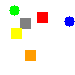

In [5]:
soc = np.load(SOC_NPZ, allow_pickle=False)

scene = 0
plt.imsave(CHAP_DATASETS / 'soc_example.png', soc['images'][scene][..., ::-1])   # stored BGR (cv2)
display(Image(CHAP_DATASETS / 'soc_example.png'))

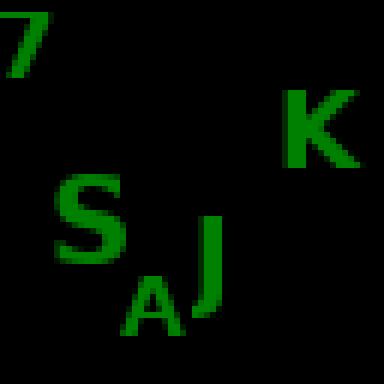

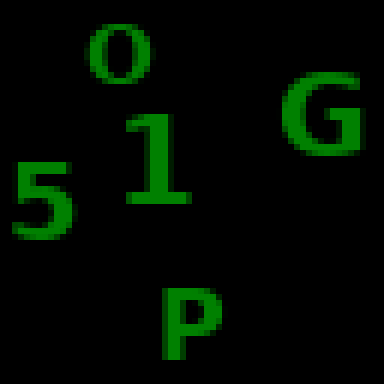

In [6]:
sq = np.load(SQOOP_NPZ, allow_pickle=True)

for i in range(2):
    plt.imsave(CHAP_DATASETS / f'sqoop_example_{i}.png', np.kron(sq['images'][i], np.ones((6, 6, 1), dtype=np.uint8)))
    display(Image(CHAP_DATASETS / f'sqoop_example_{i}.png'))

# Chapter 5.1 — Sort-of-CLEVR

In [7]:
# Table 5.1
soc_results = table(MAIN[SOC], METRICS[SOC], SOC)
soc_results.insert(0, 'Params', [f"{runs(SOC, h).n_params.iloc[0] / 1e6:.2f}M" if len(runs(SOC, h)) else '—' for h in MAIN[SOC].values()])
save(soc_results, 'soc_results')


,Params,Overall,Non-relational,Binary,Ternary
Q-Only,0.02M,49.4 ± 0.2 (5),50.7 ± 0.3 (5),43.6 ± 0.5 (5),54.1 ± 0.2 (5)
CNN+MLP,1.39M,64.7 ± 0.1 (5),63.3 ± 0.3 (5),74.5 ± 0.2 (5),56.2 ± 0.2 (5)
RelNet,0.85M,87.4 ± 1.2 (5),99.9 ± 0.0 (5),95.6 ± 0.5 (5),66.6 ± 3.1 (5)
FiLM,2.78M,93.6 ± 0.4 (5),99.9 ± 0.1 (5),97.4 ± 0.2 (5),83.5 ± 0.9 (5)
Transformer,0.30M,83.9 ± 3.7 (5),100.0 ± 0.0 (5),88.8 ± 6.9 (5),63.0 ± 5.1 (5)
Workspace,0.56M,85.8 ± 4.5 (5),100.0 ± 0.0 (5),90.3 ± 6.8 (5),67.2 ± 8.0 (5)
SyncNet,0.67M,92.4 ± 0.9 (5),100.0 ± 0.0 (5),98.8 ± 0.2 (5),78.5 ± 2.7 (5)


In [8]:
# Table 5.2 (main rows) and the appendix rows
MAIN_ROWS = ['canonical', 'no_bias', 'hard_partition', 'anchors_off', 'cells_off', 'silent', 'static_addr', 'lines_attn', 'seed_random']
col, thr = ASSEMBLED
ablations = pd.DataFrame(index=ABLATION_ROWS)
ablations['SoC accuracy'] = [fmt(SOC, ABLATIONS[SOC][r], METRICS[SOC]['Overall']) for r in ABLATION_ROWS]
ablations['SoC ternary'] = [fmt(SOC, ABLATIONS[SOC][r], METRICS[SOC]['Ternary']) for r in ABLATION_ROWS]
ablations['SoC assembled'] = [f"{(runs(SOC, ABLATIONS[SOC][r])[col] > thr).sum()}/{len(runs(SOC, ABLATIONS[SOC][r]))}" if len(runs(SOC, ABLATIONS[SOC][r])) else '—' for r in ABLATION_ROWS]
for v in (1, 18):
    ablations[f'SQOOP held-out ({v})'] = [fmt(SQ, ABLATIONS[SQ][v][r], METRICS[SQ]['held-out']) for r in ABLATION_ROWS]
save(ablations.loc[MAIN_ROWS], 'ablations')
save(ablations.drop(MAIN_ROWS), 'ablations_extra')


,SoC accuracy,SoC ternary,SoC assembled,SQOOP held-out (1),SQOOP held-out (18)
with_prior_term,—,—,—,71.0 ± 11.7 (2),99.9 ± 0.1 (4)
cnn_stem,90.5 ± 1.3 (5),75.1 ± 3.4 (5),5/5,—,—


In [9]:
# Table 5.3
drops = {k: f'test_interventions/{v}_drop' for k, v in INTERVENTIONS.items()}
interventions = pd.concat([table({'Sort-of-CLEVR': MAIN[SOC]['SyncNet']}, drops, SOC), table({'SQOOP (18)': MAIN[SQ]['SyncNet'][18], 'SQOOP (1)': MAIN[SQ]['SyncNet'][1]}, drops, SQ)])
save(interventions, 'interventions')


,Freeze,Zero,Shuffle,Anchor shuffle
Sort-of-CLEVR,67.5 ± 9.6 (5),57.1 ± 15.3 (5),11.7 ± 13.2 (5),35.6 ± 4.2 (5)
SQOOP (18),—,—,—,—
SQOOP (1),—,—,—,—


# Chapter 5.2 — SQOOP

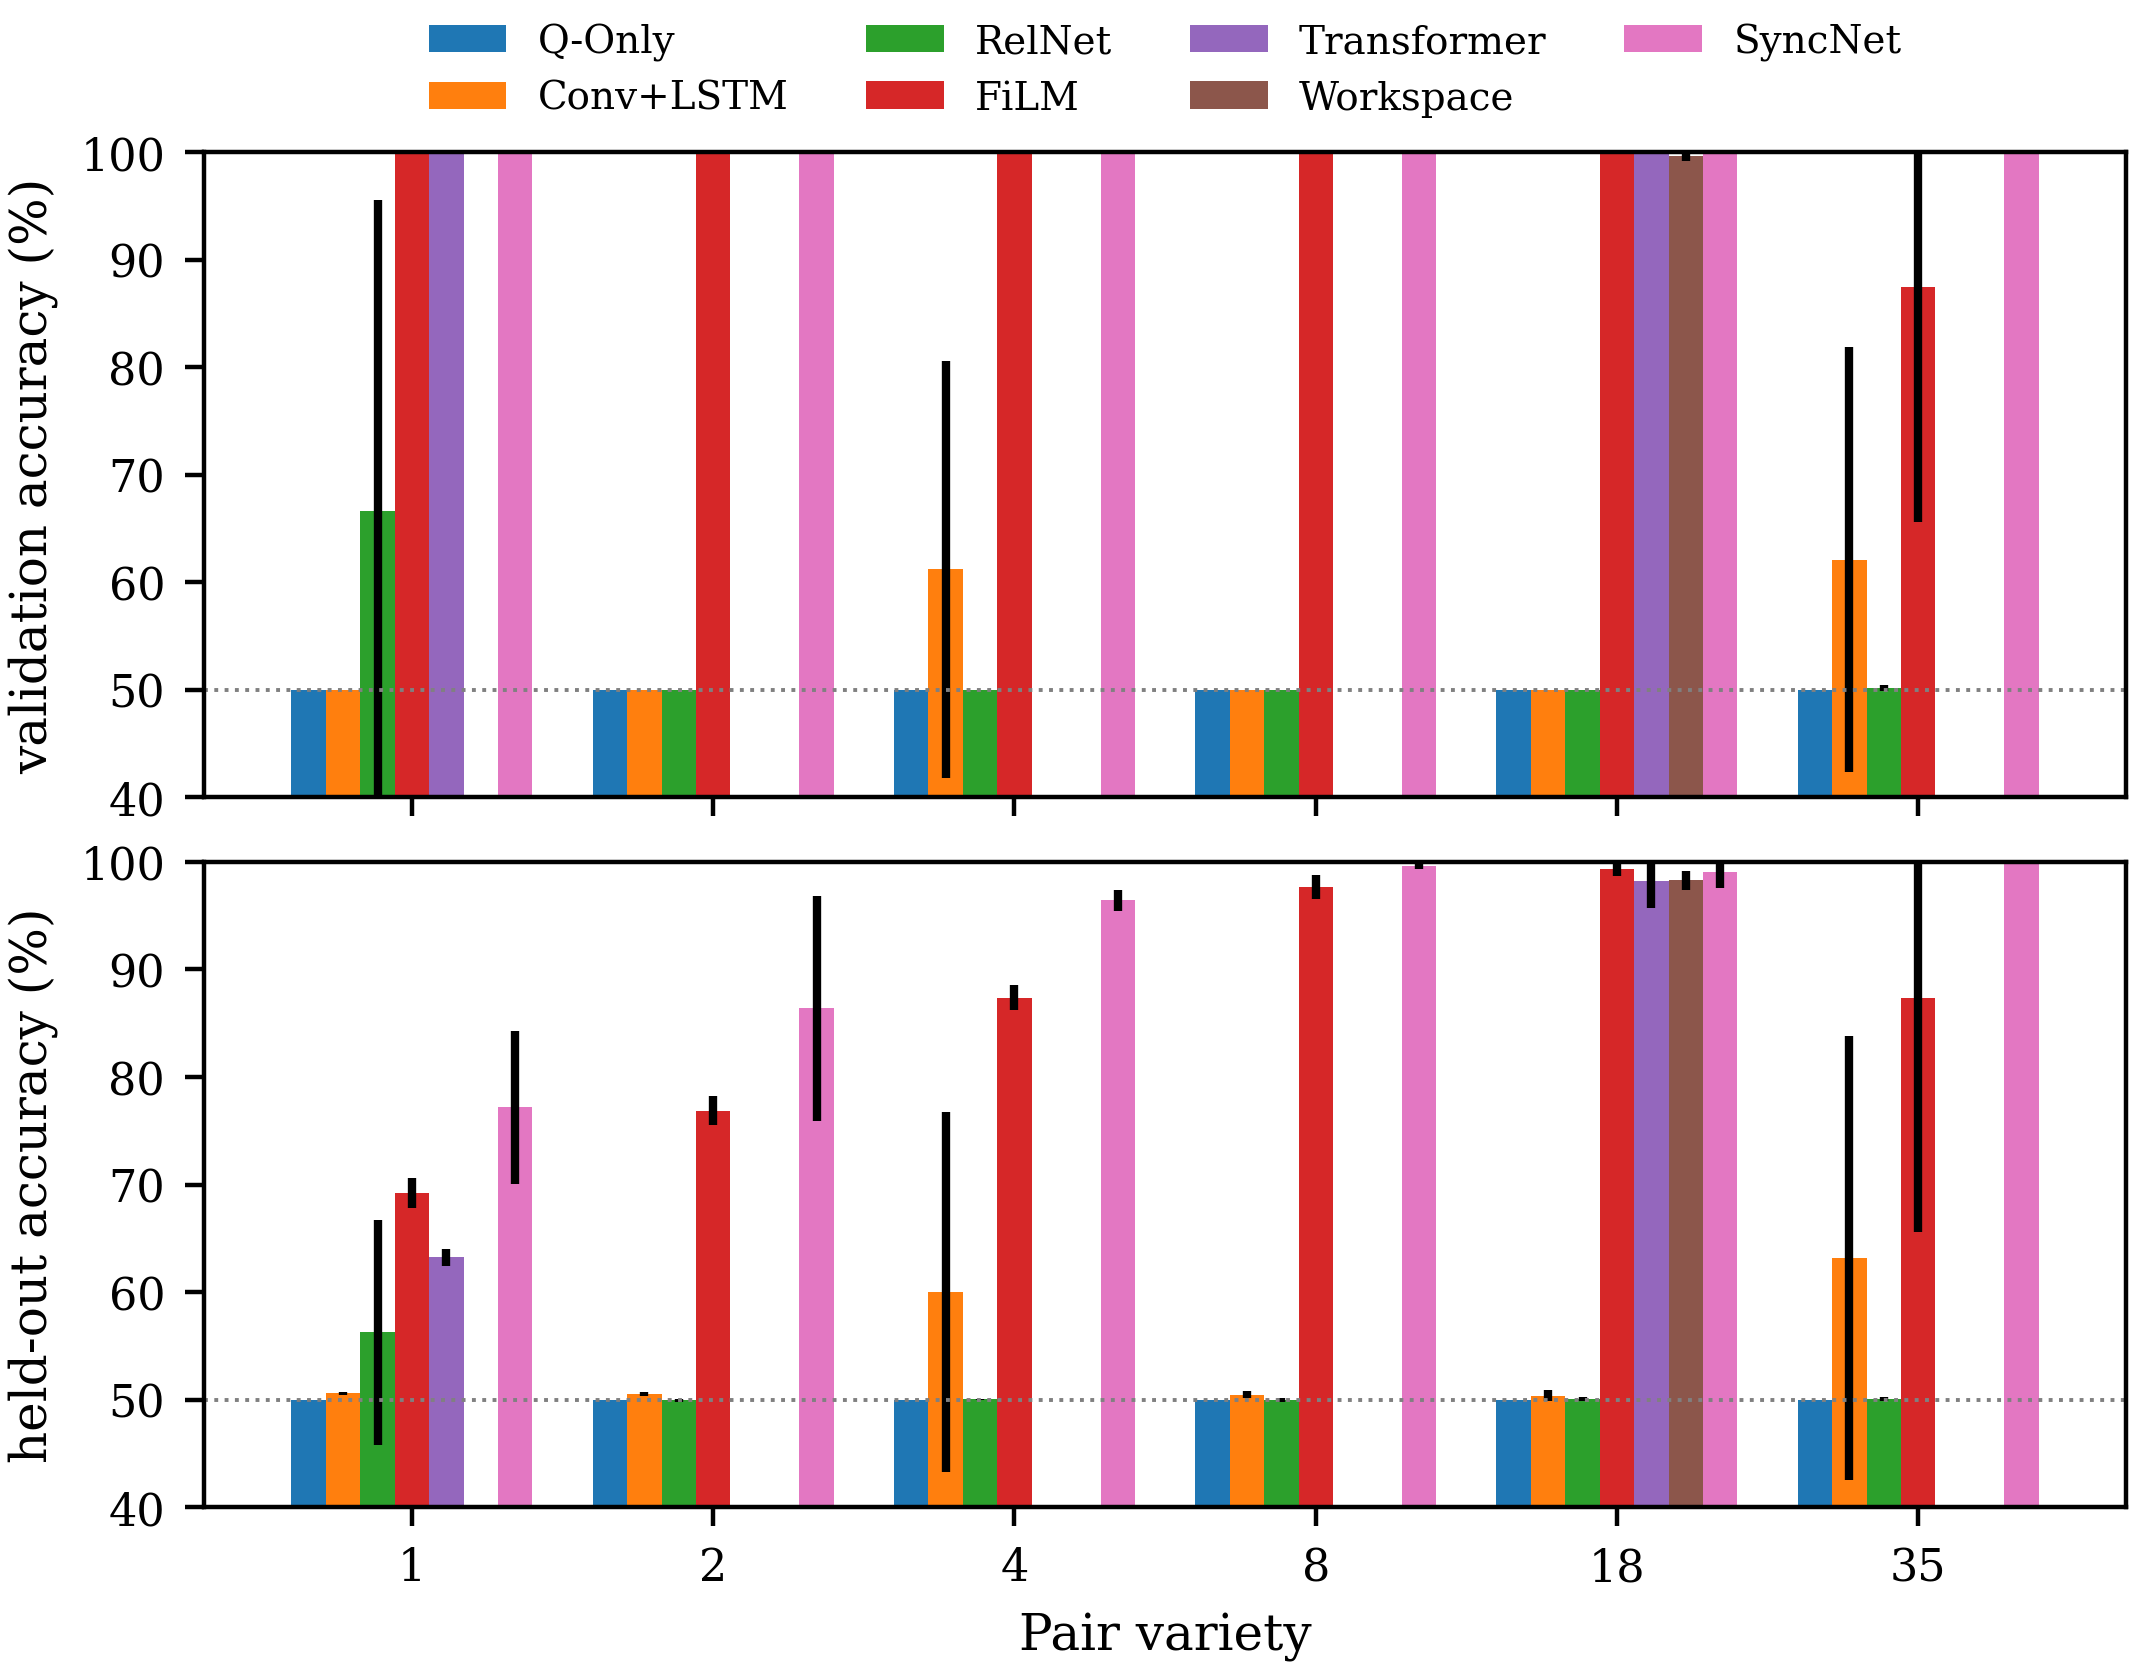

In [10]:
# Figure 5.2
models = [m for m in MAIN[SQ] if any(stat(SQ, h, METRICS[SQ]['held-out'])[2] for h in MAIN[SQ][m].values())]
x = np.arange(len(PAIR_VARIETY)); w = 0.8 / len(models)
fig, axes = plt.subplots(2, 1, figsize=(6.2, 4.4), sharex=True)
for ax, (split, col) in zip(axes, METRICS[SQ].items()):
    for k, m in enumerate(models):
        mean, sd = zip(*[stat(SQ, MAIN[SQ][m][v], col)[:2] for v in PAIR_VARIETY])
        ax.bar(x + (k - len(models) / 2 + 0.5) * w, mean, w, yerr=sd, label=m)
    ax.axhline(50, color='grey', linestyle=':', linewidth=0.7); ax.set_ylim(40, 100); ax.set_ylabel(f'{split} accuracy (%)')
axes[-1].set_xticks(x, PAIR_VARIETY); axes[-1].set_xlabel('Pair variety')
axes[0].legend(frameon=False, fontsize=7, ncol=4, loc='lower center', bbox_to_anchor=(0.5, 1.0))
fig.subplots_adjust(hspace=0.1)
save_show(fig, 'sqoop_results_bars_stacked', CHAP_RESULTS)


/tmp/ipykernel_2017795/689413219.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.set_xlabel(xlabel); ax.set_ylabel('Accuracy (%)'); ax.legend(frameon=False, fontsize=7)


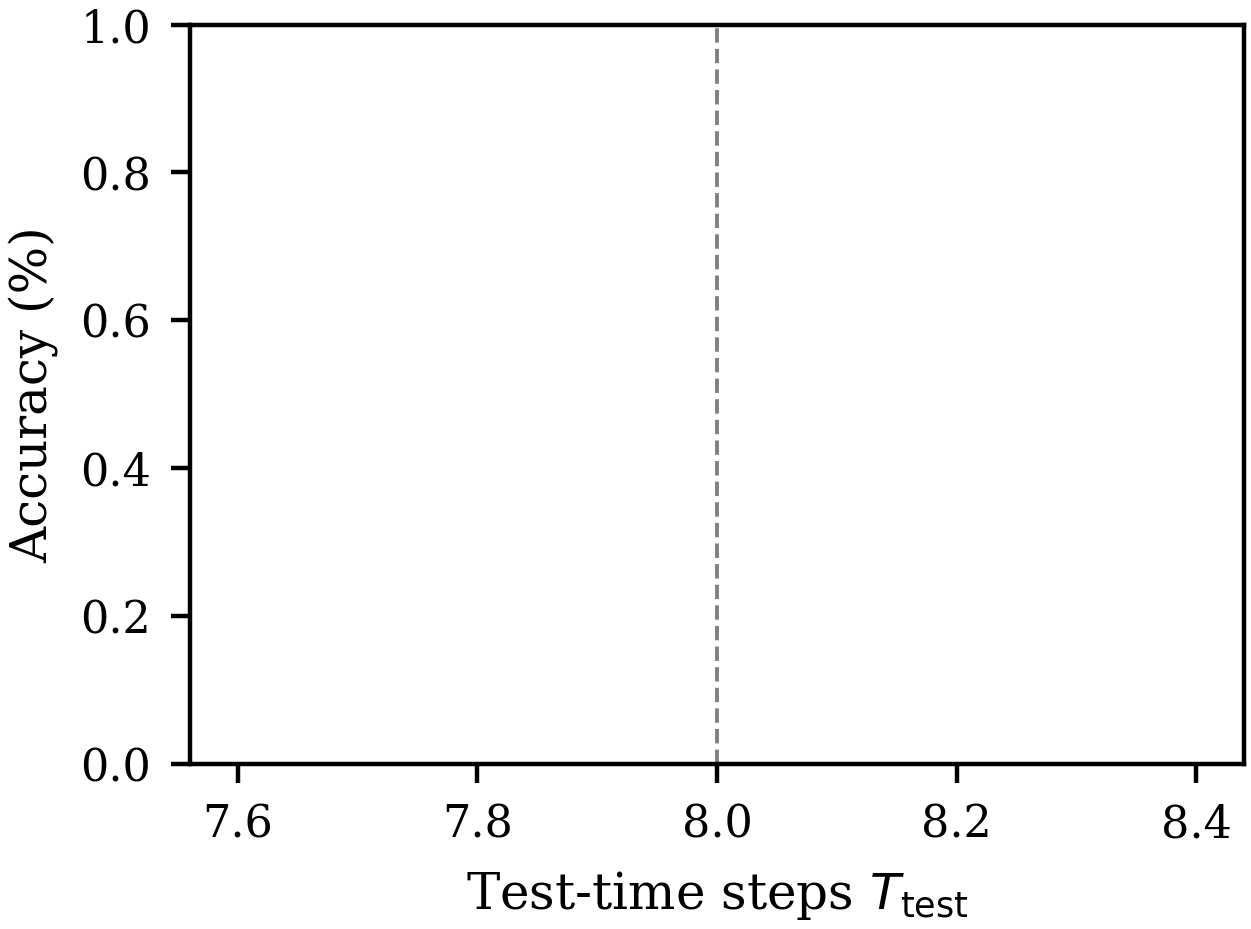

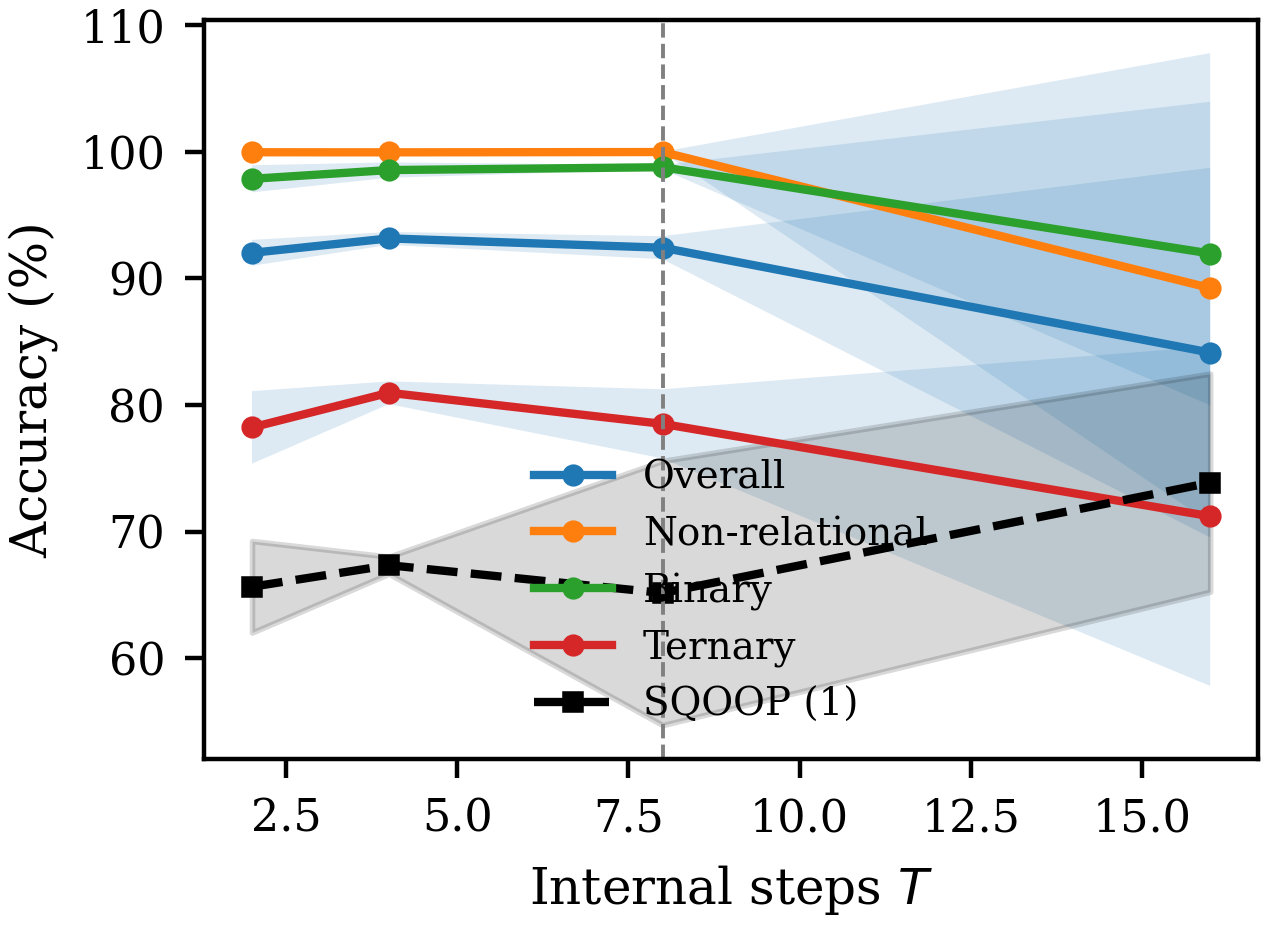

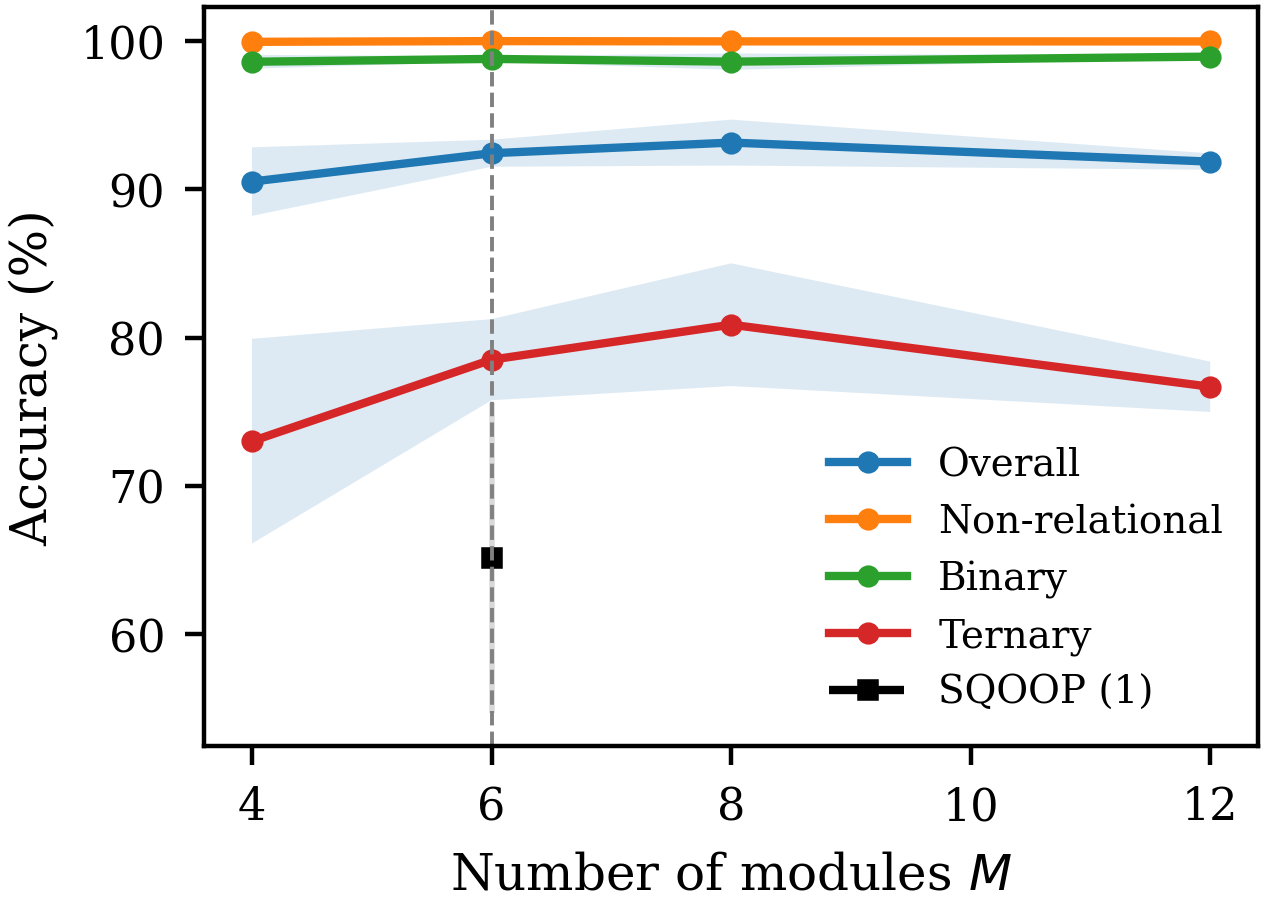

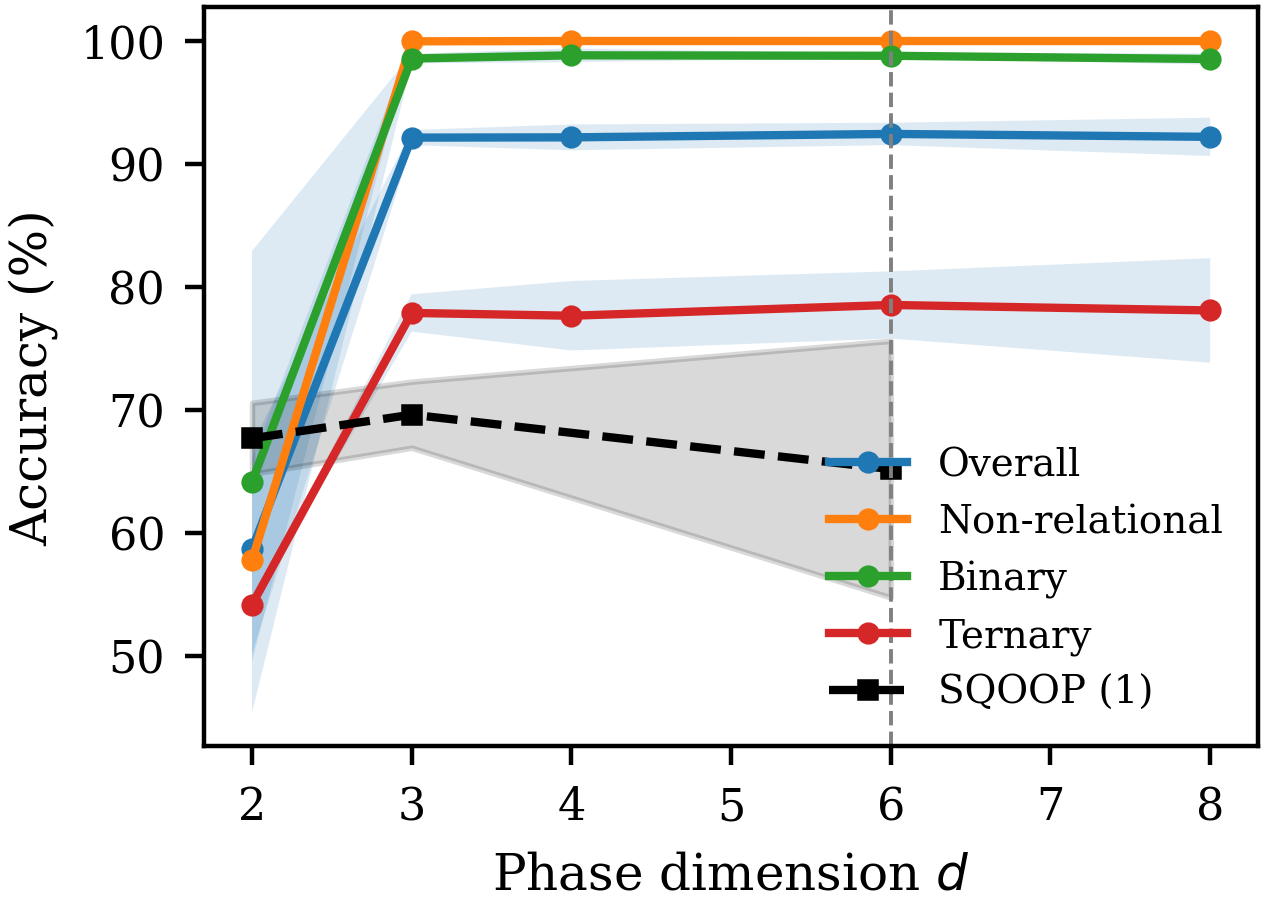

In [11]:
# Figure 5.4 (closes the chapter)
def sweep(axis, xlabel, name, cols=lambda x: METRICS[SOC]):
    fig, ax = plt.subplots(figsize=(3.4, 2.4))
    series = [(fam, SOC, SWEEPS[SOC][axis], cols, {}) for fam in METRICS[SOC]]
    series += [('SQOOP (1)', SQ, SWEEPS[SQ][1].get(axis, {}), lambda x: {'SQOOP (1)': METRICS[SQ]['held-out']}, {'color': 'k', 'linestyle': '--', 'marker': 's'})]
    for label, task, cells, cols_, style in series:
        pts = [(x, *stat(task, h, cols_(x).get(label))[:2]) for x, h in cells.items()]
        pts = [p for p in pts if not np.isnan(p[1])]
        if pts:
            x, m, s = map(np.array, zip(*pts))
            ax.plot(x, m, label=label, markersize=3, **({'marker': 'o'} | style))
            ax.fill_between(x, m - s, m + s, alpha=0.15, color=style.get('color'))
    canon = main.get({'t_train': 'model.t_bus', 'phase_dim': 'model.phase_dim', 'n_modules': 'model.n_modules'}.get(axis, 'model.t_bus'))
    if pd.notna(canon): ax.axvline(canon, color='grey', linestyle='--', linewidth=0.7)
    ax.set_xlabel(xlabel); ax.set_ylabel('Accuracy (%)'); ax.legend(frameon=False, fontsize=7)
    save_show(fig, name, CHAP_RESULTS)


SWEEPS[SOC]['t_test'] = {T: MAIN[SOC]['SyncNet'] for T in T_TEST}
sweep('t_test', r'Test-time steps $T_{\mathrm{test}}$', 'soc_ablation_t_test', cols=lambda T: {fam: col.format(T) for fam, col in T_VARIANCE.items()})
sweep('t_train', r'Internal steps $T$', 'soc_ablation_t_train')
sweep('n_modules', r'Number of modules $M$', 'soc_ablation_n_modules')
sweep('phase_dim', r'Phase dimension $d$', 'soc_ablation_phase_dim')


# Appendix

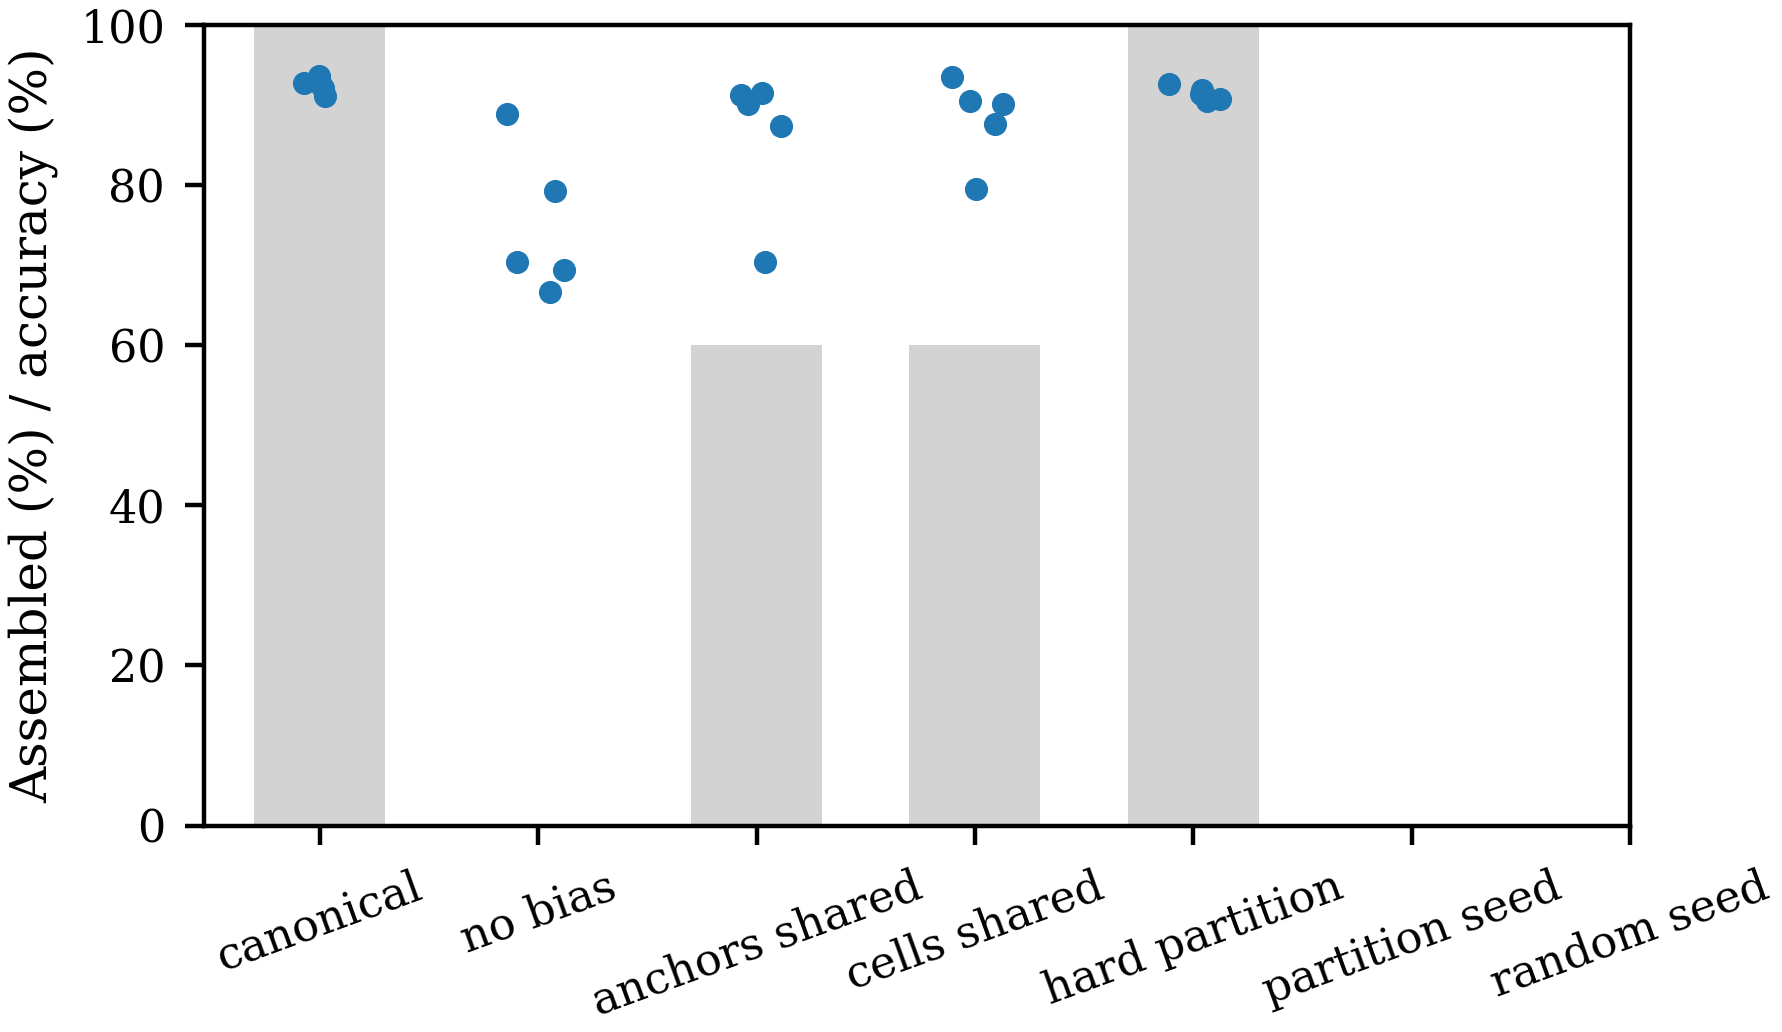

In [12]:
# Appendix: assembly-rate figure
variants = {'canonical': ABLATIONS[SOC]['canonical'], 'no bias': ABLATIONS[SOC]['no_bias'], 'anchors shared': ABLATIONS[SOC]['anchors_off'], 'cells shared': ABLATIONS[SOC]['cells_off'], 'hard partition': ABLATIONS[SOC]['hard_partition'], 'partition seed': SEEDING[SOC]['partition'], 'random seed': SEEDING[SOC]['random']}
col, thr = ASSEMBLED
fig, ax = plt.subplots(figsize=(4.6, 2.6))
for i, (label, h) in enumerate(variants.items()):
    r = runs(SOC, h)
    if r.empty: continue
    ax.bar(i, 100 * (r[col] > thr).mean(), color='lightgrey', width=0.6)
    ax.scatter(i + np.random.uniform(-0.15, 0.15, len(r)), 100 * r[METRICS[SOC]['Overall']], s=10, color='C0', zorder=3)
ax.set_xticks(range(len(variants)), list(variants), rotation=20)
ax.set_ylabel('Assembled (%) / accuracy (%)'); ax.set_ylim(0, 100)
save_show(fig, 'soc_assembly_rate', CHAP_RESULTS)


In [13]:
# Appendix: gradient agreement
p = Path('results/gradient_agreement.csv')
if p.exists():
    ga = pd.read_csv(p)
    fig, axes = plt.subplots(1, 2, figsize=(6.2, 2.5))
    for ax, col, ylabel in zip(axes, ['snr', 'cosine'], [r'$\|\bar g\|\,/\,\overline{\|g_i\|}$', 'pairwise cosine']):
        for (task, model), g in ga.groupby(['task', 'model']):
            ax.plot(g['batch'], g[col], marker='o', markersize=3, label=f'{task} {model}')
        ax.set_xscale('log', base=2); ax.set_xlabel('batch size'); ax.set_ylabel(ylabel)
    axes[0].axhline(1 / np.sqrt(8), color='grey', linestyle=':', linewidth=0.7); axes[0].legend(frameon=False, fontsize=6)
    save_show(fig, 'gradient_agreement', CHAP_RESULTS)


In [14]:
TRAINING = {'Optimiser': 'optim.optimiser', 'Learning rate': 'optim.lr', 'Weight decay': 'optim.weight_decay', 'Schedule': 'optim.lr_scheduler', 'Warmup steps': 'optim.lr_scheduler_params.warmup_steps', 'Batch size': 'train.train_bs', 'Gradient clipping': 'train.grad_clip', 'Optimisation steps': 'train.n_steps', 'Precision': 'train.mixed_precision', 'Compilation': 'train.compile_model'}
save(pd.Series({k: main.get(c, '—') for k, c in TRAINING.items()}, name='value').to_frame(), 'training')


,value
Optimiser,adamw
Learning rate,0.0003
Weight decay,0.01
Schedule,warmup_cosine
Warmup steps,2000
Batch size,256
Gradient clipping,1
Optimisation steps,100000
Precision,bf16
Compilation,True


In [15]:
sub = {('Overall', ''): METRICS[SOC]['Overall']}
for fam, subs in SUBTYPES.items():
    sub[(fam, '')] = METRICS[SOC][fam]
    sub |= {(fam, name): f'test_callbacks/{key}_accuracy' for name, key in subs.items()}
save(table(MAIN[SOC], sub, SOC).T, 'soc_subtypes')

save(pd.DataFrame({v: {(m, split): fmt(SQ, MAIN[SQ][m].get(v), col) for m in MAIN[SQ] for split, col in METRICS[SQ].items()} for v in PAIR_VARIETY}), 'sqoop_results')

save(pd.DataFrame({(axis, x): {'SoC': fmt(SOC, h, METRICS[SOC]['Overall']), 'SQOOP (1)': fmt(SQ, SWEEPS[SQ][1].get(axis, {}).get(x), METRICS[SQ]['held-out'])} for axis, cells in SWEEPS[SOC].items() if axis != 't_test' for x, h in cells.items()}).T, 'sweeps')

save(pd.concat([table(SEEDING[SOC], METRICS[SOC], SOC), table(SEEDING[SQ][18], METRICS[SQ], SQ)]), 'seeding')

save(pd.concat([pd.DataFrame({(m, v): fmt(SOC, h, METRICS[SOC]['Overall']) for m, vs in BASELINE_VARIANTS[SOC].items() for v, h in vs.items()}, index=['Sort-of-CLEVR']).T,
                pd.DataFrame({(m, v): fmt(SQ, h, METRICS[SQ]['held-out']) for m, vs in BASELINE_VARIANTS[SQ][18].items() for v, h in vs.items()}, index=['SQOOP (18)']).T], axis=1), 'baseline_variants')


Sort-of-CLEVR      SQOOP (18)
Transformer patchify           83.9 ± 3.7 (5)  50.0 ± 0.0 (5)
            stem                            —               —
            stem + 4 layers                 —             NaN
Workspace   patchify           85.8 ± 4.5 (5)  59.3 ± 9.3 (5)
            stem                            —               —
RelNet      5x5                87.4 ± 1.2 (5)  50.1 ± 0.2 (5)
            8x8                             —               —
Transformer stem + batch 2048             NaN               —
Workspace   stem + batch 2048             NaN               —
Conv+LSTM   base                          NaN  50.4 ± 0.5 (5)
            tuned                         NaN               —